# Project Report Draft 1   

## Introduction

In this report, we aim to explore housing affordability in Metro Vancouver, through analysis of the “Housing Affordability for New Homeowners in B.C., Census Metropolitan Areas Quarterly Data 2025 Q3” dataset obtained from the B.C. Data Catalogue. The complete dataset contains data from all major cities in BC, gathered quarterly. The data was gathered to improve affordability across BC. This data was collected through a combined effort by Statistics Canada, Bank of Canada and BC Assessment, and compiled by BC Stats. They used informational sources such as CRA tax returns, CPI surveys, and property information gathered via BC assessments.
Source: https://catalogue.data.gov.bc.ca/dataset/b-c-housing-affordability/resource/a71e6838-cda1-4acb-adfb-8515c4f9fec9

As students currently struggling with affordability in Metro Vancouver, we wanted to investigate housing affordability trends in this area and its association to variables such as housing prices, the prime rate, and family income. Specifically, we want to know how interest rates and median family income affect median housing price, after accounting for housing type and number of resales. This will help us understand the key factors driving market price, and potentially derive our own conclusions on affordability trends.

### Variables

| Variable Name(s) | Type | Description |
|------------------|------|-------------|
| CMA ID | Integer | Census metropolitan area ID/Name assigned by Statistics Canada, which corresponds to population centres. See the definition on their website. |
| CMA NAME | Categorical | Census metropolitan area ID/Name assigned by Statistics Canada, which corresponds to population centres. |
| YEAR | Integer | Each row is specified by a combination of YEAR, QUARTER and HOUSING TYPE. YEAR value ranges from 2000 to 2025. |
| QUARTER | Integer | QUARTER value ranges from 1 to 4 (Q1–Q4), up to 2025 Q3. |
| HOUSING TYPE | Categorical | HOUSING TYPE values is one of the values in this set: {Single-detached, Apartment, Row Housing, All Housing Types}. |
| MEDIAN HOUSING PRICE | Integer | Sale price for a particular year/quarter/house-type. (CAD) |
| MEDIAN AFTER TAX FAMILY ANNUAL INCOME | Float | Estimated quarterly median family income. (CAD) |
| PRIME INTEREST RATE | Float | Base loan interest rate used to estimate mortgage rates. (%) |
| MORTGAGE PAYMENT PERCENT INCOME (MPPI) | Float | Affordability metric based on median after-income tax, home price, minimum down payment, and 25-year variable rate mortgage (based on prime). Higher means less affordable (% of income). |
| HISTORIC PAYMENT PERCENT INCOME | Float | Long-term running average of MPPI used as benchmark, calculated using MPPI from 2000–2025. |
| NUMBER OF RESALES | Integer | Resale count per quarter. (Count of homes). |

In [33]:
library(janitor, quietly = T)
library(tidyverse, quietly = T)
library(car, quietly = T)
library(broom, quietly = T)

In [2]:
data = read.csv("bc-data-catalogue-cma-2025-q3.csv")
head(data)
glimpse(data)

,CMA.ID,CMA.NAME,YEAR,QUARTER,HOUSING.TYPE,MEDIAN.HOUSING.PRICE,MEDIAN.AFTER.TAX.ANNUAL.FAMILY.INCOME,PRIME.INTEREST.RATE,MORTGAGE.PAYMENT.PERCENT.INCOME,HISTORIC.PAYMENT.PERCENT.INCOME,NUMBER.OF.RESALES
,<int>,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,932,Abbotsford - Mission,2000,1,All housing types,180000,40110,6.673077,35.17395,39.85805,211
2,932,Abbotsford - Mission,2000,1,Condos,85000,40110,6.673077,16.60992,20.09532,25
3,932,Abbotsford - Mission,2000,1,Single-detached,198000,40110,6.673077,38.69134,49.93105,151
4,932,Abbotsford - Mission,2000,1,Townhouses,159839,40110,6.673077,31.23427,32.71123,35
5,944,Campbell River,2000,1,All housing types,136000,44950,6.673077,23.71431,28.83969,61
6,944,Campbell River,2000,1,Condos,88250,44950,6.673077,15.38815,18.33500,10


Rows: 8,475
Columns: 11
$ CMA.ID                                <int> 932, 932, 932, 932, 944, 944, 94…
$ CMA.NAME                              <chr> "Abbotsford - Mission", "Abbotsf…
$ YEAR                                  <int> 2000, 2000, 2000, 2000, 2000, 20…
$ QUARTER                               <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,…
$ HOUSING.TYPE                          <chr> "All housing types", "Condos", "…
$ MEDIAN.HOUSING.PRICE                  <dbl> 180000.0, 85000.0, 198000.0, 159…
$ MEDIAN.AFTER.TAX.ANNUAL.FAMILY.INCOME <dbl> 40110, 40110, 40110, 40110, 4495…
$ PRIME.INTEREST.RATE                   <dbl> 6.673077, 6.673077, 6.673077, 6.…
$ MORTGAGE.PAYMENT.PERCENT.INCOME       <dbl> 35.17395, 16.60992, 38.69134, 31…
$ HISTORIC.PAYMENT.PERCENT.INCOME       <dbl> 39.85805, 20.09532, 49.93105, 32…
$ NUMBER.OF.RESALES                     <int> 211, 25, 151, 35, 61, 10, 46, 10…


In [3]:
vancouver_data <- data |>
    filter(CMA.NAME == "Vancouver") |>
    clean_names()

head(vancouver_data)

,cma_id,cma_name,year,quarter,housing_type,median_housing_price,median_after_tax_annual_family_income,prime_interest_rate,mortgage_payment_percent_income,historic_payment_percent_income,number_of_resales
,<int>,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,933,Vancouver,2000,1,All housing types,239500.0,42730,6.673077,43.93129,46.34979,3944
2,933,Vancouver,2000,1,Condos,159839.0,42730,6.673077,29.31913,33.52102,1245
3,933,Vancouver,2000,1,Single-detached,288500.0,42730,6.673077,52.91931,73.63157,2146
4,933,Vancouver,2000,1,Townhouses,205781.0,42730,6.673077,37.74624,42.89967,553
5,933,Vancouver,2000,2,All housing types,244492.9,42730,7.269231,47.32921,46.34979,5615
6,933,Vancouver,2000,2,Condos,157699.7,42730,7.269231,30.52768,33.52102,1567


The data was almost entirely clean from the start, there was nothing missing, and no duplicates. Since we're focusing only on Metro Vancouver, the data was filtered to only contain it. The clean_names function was also used to make the variable names easier to use for R.

## Exploratory Data Analysis 

### Summary Statistics

In [4]:
summary(vancouver_data)

     cma_id      cma_name              year         quarter     
 Min.   :933   Length:412         Min.   :2000   Min.   :1.000  
 1st Qu.:933   Class :character   1st Qu.:2006   1st Qu.:1.000  
 Median :933   Mode  :character   Median :2012   Median :2.000  
 Mean   :933                      Mean   :2012   Mean   :2.485  
 3rd Qu.:933                      3rd Qu.:2019   3rd Qu.:3.000  
 Max.   :933                      Max.   :2025   Max.   :4.000  
 housing_type       median_housing_price median_after_tax_annual_family_income
 Length:412         Min.   : 150000      Min.   :42730                        
 Class :character   1st Qu.: 345054      1st Qu.:53680                        
 Mode  :character   Median : 481951      Median :64270                        
                    Mean   : 580608      Mean   :67572                        
                    3rd Qu.: 683052      3rd Qu.:79995                        
                    Max.   :1855068      Max.   :99865                 

The dataset contains 412 observations spanning over the years 2000-2025. The median housing price ranges from approximately 150,000 to over 1.85 million, indicating substantial variation in housing values over the observed period. 
The mean housing price exceeds the median, suggesting a right-skewed plot, prompted by higher-priced properties. To reduce the skewness, stabilize variance, and satisfy the assumptions of linear regression (especially homoscedasticity), **log-transformation** will be applied to `median_housing_price`.

### Visualizations

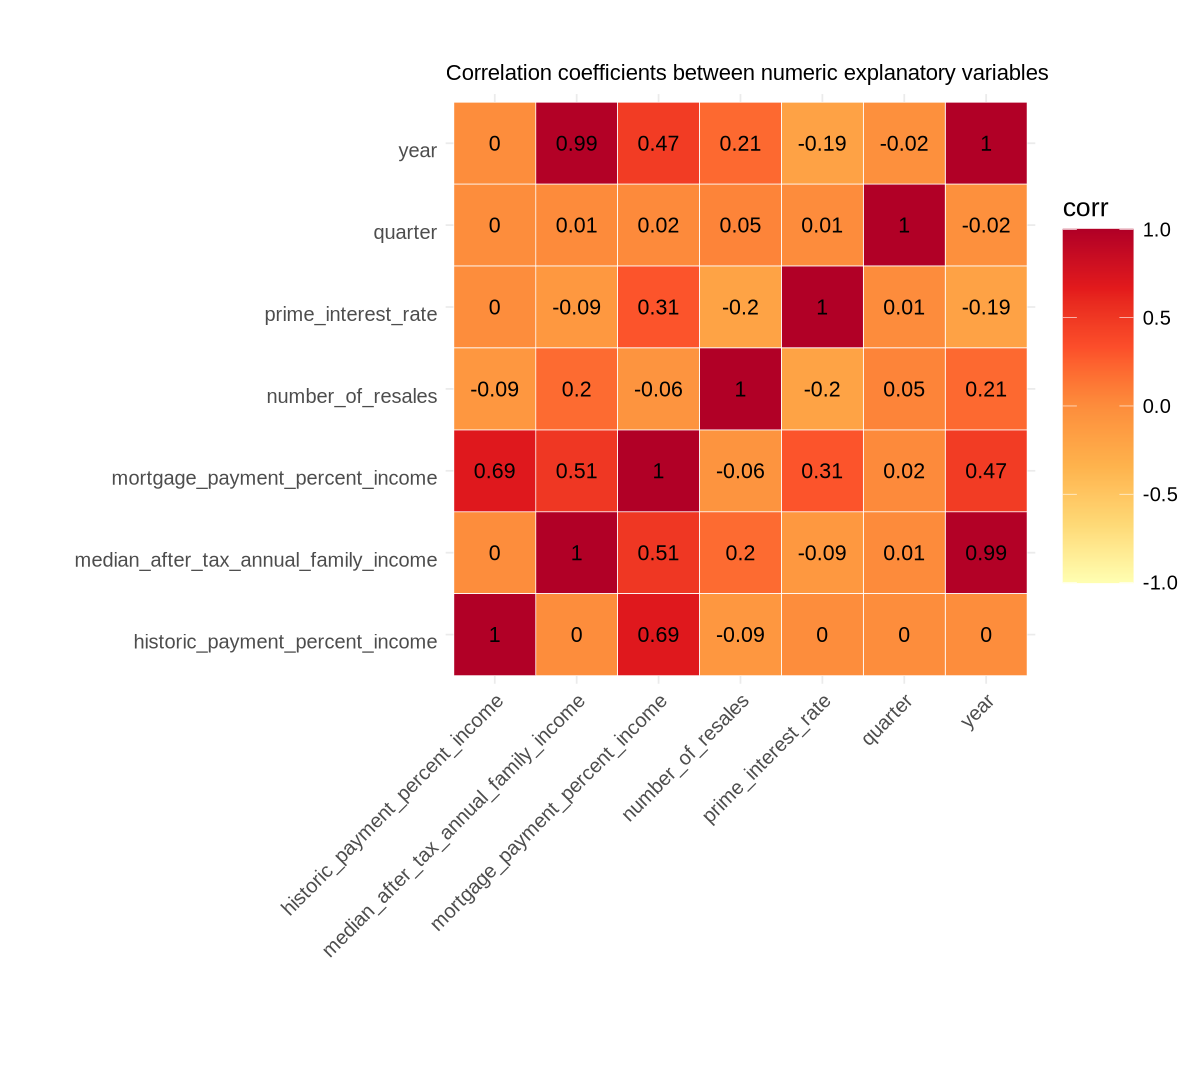

In [5]:
#Correlation heatmap of all numeric explanatory variables
corr_matrix <- vancouver_data |>
  select(where(is.numeric), -cma_id, -median_housing_price) |>
  cor() |>
  as_tibble(rownames = 'var1') |>
  pivot_longer(-var1, names_to = "var2", values_to = "corr")

options(repr.plot.width = 10, repr.plot.height = 9)

heatmap_van <- corr_matrix |>
  ggplot(aes(var1, var2, fill= corr)) +
  geom_tile(color = "white") +
  scale_fill_distiller(palette = "YlOrRd", direction = 1,  limits = c(-1, 1)) +
  labs(title = "Correlation coefficients between numeric explanatory variables", x = "", y = "") +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, vjust = 1, size = 12, hjust = 1),
    axis.text.y = element_text(vjust = 1, size = 12, hjust = 1),
    legend.title = element_text(size = 16),
    legend.text = element_text(size = 12),
    legend.key.size = unit(1.5, "cm")) + 
  coord_fixed() +
  geom_text(aes(var2, var1, label = round(corr, 2)), color = "black", size = 4.5)

heatmap_van

The heatmap above clearly portrays that some of our variables are highly correlated with each other. The covariates 'year' and 'median_after_tax_annual_family_income' seem to have a high correlation coefficient. This indicates potential multicollinearity, suggesting that it may be challenging to isolate the individual effects of these predictors.

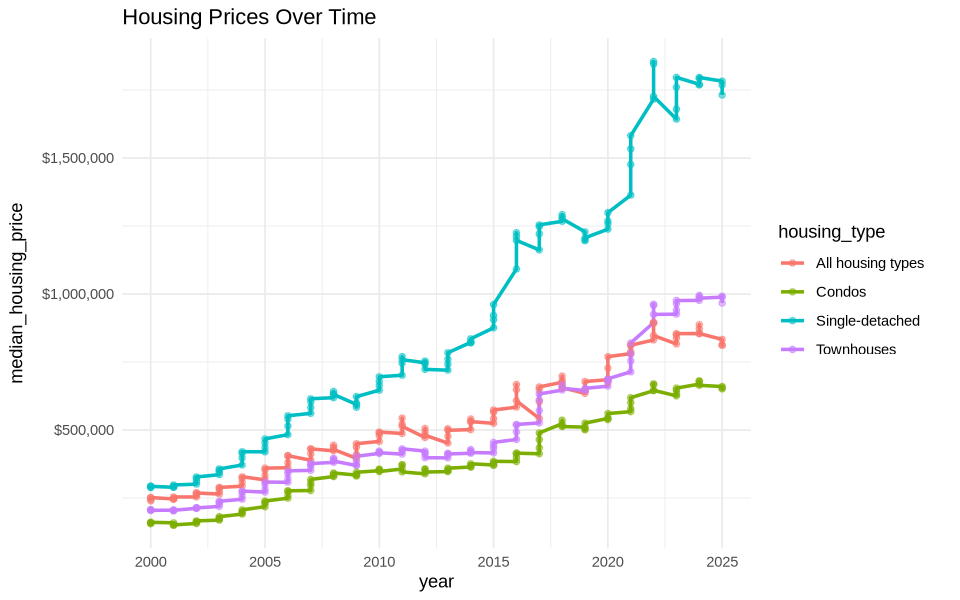

In [6]:
#Time trend
line_plot = ggplot(vancouver_data, aes(x = year, y = median_housing_price, color = housing_type)) +
  geom_line(linewidth = 1) +
  geom_point(alpha = 0.5) +
  scale_y_continuous(labels = scales::label_dollar()) +
  theme_minimal() +
  labs(title = "Housing Prices Over Time")
options(repr.plot.width = 8, repr.plot.height = 5)
line_plot

The lineplot shows a strong upward trend in median housing prices across all housing types. Single-detached houses consistently have the highest prices, followed by townhouses, while condos remain the least expensive. Price growth also seems to accelerate after 2015.

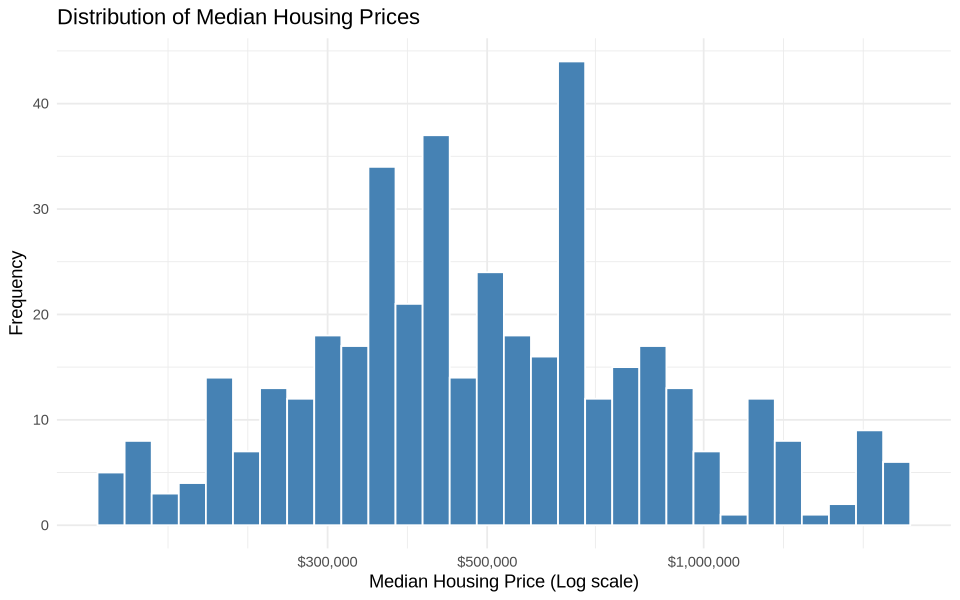

In [7]:
#log-transformed distribution
ggplot(vancouver_data, aes(x = median_housing_price)) +
  geom_histogram(bins = 30, fill = "steelblue", color = "white") +
  scale_x_log10(labels = scales::label_dollar()) +
  theme_minimal() +
  labs(
    title = "Distribution of Median Housing Prices",
    x = "Median Housing Price (Log scale)",
    y = "Frequency"
  )
options(repr.plot.width = 6, repr.plot.height = 4)

The log-transformed distribution of median housing prices seems approximately symmetric and unimodal, implying that the original right-skewness has been mitigated. The transformation makes the data more suitable for regression analysis.

## Statistical analysis

We will scale some of the covariates to make interpreting the result of the model easier, namely dividing `median_after_tax_annual_family_income` by 10000, and `number_of_resales` by 100.

In [8]:
vancouver_data <- vancouver_data |>
  mutate(income_10k = median_after_tax_annual_family_income / 10000,
         resales_100 = number_of_resales / 100)
head(vancouver_data)

,cma_id,cma_name,year,quarter,housing_type,median_housing_price,median_after_tax_annual_family_income,prime_interest_rate,mortgage_payment_percent_income,historic_payment_percent_income,number_of_resales,income_10k,resales_100
,<int>,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,933,Vancouver,2000,1,All housing types,239500.0,42730,6.673077,43.93129,46.34979,3944,4.273,39.44
2,933,Vancouver,2000,1,Condos,159839.0,42730,6.673077,29.31913,33.52102,1245,4.273,12.45
3,933,Vancouver,2000,1,Single-detached,288500.0,42730,6.673077,52.91931,73.63157,2146,4.273,21.46
4,933,Vancouver,2000,1,Townhouses,205781.0,42730,6.673077,37.74624,42.89967,553,4.273,5.53
5,933,Vancouver,2000,2,All housing types,244492.9,42730,7.269231,47.32921,46.34979,5615,4.273,56.15
6,933,Vancouver,2000,2,Condos,157699.7,42730,7.269231,30.52768,33.52102,1567,4.273,15.67


### Model Selection

In [14]:
full_model <- lm(log(median_housing_price) ~ 
                 year + quarter + housing_type + prime_interest_rate + income_10k + 
                 mortgage_payment_percent_income + historic_payment_percent_income + resales_100, data = vancouver_data)
alias(full_model)

Model :
log(median_housing_price) ~ year + quarter + housing_type + prime_interest_rate + 
    income_10k + mortgage_payment_percent_income + historic_payment_percent_income + 
    resales_100

Complete :
                                (Intercept)   year          quarter      
historic_payment_percent_income  676846/14603             0             0
                                housing_typeCondos housing_typeSingle-detached
historic_payment_percent_income -435524/33949          12877/472              
                                housing_typeTownhouses prime_interest_rate
historic_payment_percent_income -132947/38534                      0      
                                income_10k    mortgage_payment_percent_income
historic_payment_percent_income             0             0                  
                                resales_100  
historic_payment_percent_income             0


From the above, we see that `historic_payment_percent_income` can be expressed as a linear combination of other covariates, so we will remove them in order to find VIF values.

In [15]:
noalias_model <- lm(log(median_housing_price) ~ 
                 year + quarter + housing_type + prime_interest_rate + income_10k + 
                 mortgage_payment_percent_income + resales_100, data = vancouver_data)
vif(noalias_model)

,GVIF,Df,GVIF^(1/(2*Df))
year,85.068557,1,9.223262
quarter,1.114402,1,1.055652
housing_type,20.780986,3,1.658101
prime_interest_rate,3.185203,1,1.784714
income_10k,80.281888,1,8.960016
mortgage_payment_percent_income,8.075838,1,2.841802
resales_100,4.851840,1,2.202689


From the above, we see that `year`, `income_10k`, `housing_type` all have VIF values >10, suggesting multicollinearity as we previously pointed out during EDA. We will drop `year` as our research question would like to find relationship between housing prices and other variables including income. From the technical notes in the BC Data Catalogue on our dataset, we know that MPPI (`mortgage_payment_percent_income`) is calculated using median housing prices and prime interest rate, hence we will also drop this variable.

In [21]:
vif_model <- lm(log(median_housing_price) ~ 
              housing_type + income_10k + quarter+
              prime_interest_rate + resales_100, data = vancouver_data)
vif(vif_model)

,GVIF,Df,GVIF^(1/(2*Df))
housing_type,4.264022,3,1.273415
income_10k,1.156558,1,1.075434
quarter,1.011980,1,1.005972
prime_interest_rate,1.159549,1,1.076823
resales_100,4.602533,1,2.145352


We observe that after removal of the two covariates, the VIF values have greater improved to less concerning level below our rule-of-thumb value of 10, suggesting that we have dealt with the multicollinearity problem between our covariates. We will now do model selection to see if we can find a simpler model to interpret with similar performance.

In [24]:
m1 <- lm(log(median_housing_price) ~ housing_type + income_10k + prime_interest_rate, data = vancouver_data)
m2 <- lm(log(median_housing_price) ~ housing_type + income_10k + prime_interest_rate + resales_100, data = vancouver_data)
m3 <- lm(log(median_housing_price) ~ housing_type + income_10k + prime_interest_rate + quarter, data = vancouver_data)
m4 <- lm(log(median_housing_price) ~ housing_type + income_10k + prime_interest_rate + resales_100 + quarter, data = vancouver_data)

n <- nrow(vancouver_data)
q <- 5

ssres_base <- deviance(m1)
ssres_resales <- deviance(m2)
ssres_quarter <- deviance(m3)
ssres_full <- deviance(m4)

ssres_values <- c(ssres_base, ssres_resales, ssres_quarter, ssres_full)
p_covariates <- c(3, 4, 4, 5)
full_model <- lm(log(median_housing_price) ~ housing_type + income_10k + prime_interest_rate + resales_100 + quarter, data = vancouver_data)
mse_full <- deviance(full_model) / full_model$df.residual

p_params <- c(length(coef(m1)), length(coef(m2)), length(coef(m3)), length(coef(m4)))
Cps <- ssres_values / mse_full - (n - 2 * p_params)

tibble(p_params = p_params,
  SSRes = round(ssres_values, 4),
  Cp = round(Cps, 2),
  Adj_R2 = c(summary(m1)$adj.r.squared, summary(m2)$adj.r.squared, 
             summary(m3)$adj.r.squared, summary(m4)$adj.r.squared))

p_params,SSRes,Cp,Adj_R2
<int>,<dbl>,<dbl>,<dbl>
6,5.8831,6.83,0.9539540
7,5.8625,7.41,0.9540015
7,5.8671,7.72,0.9539658
8,5.8421,8.00,0.9540480


To finalize our predictive model, we compared four candidate subsets using Adjusted $R^2$ and Mallows' $C_p$ criteria. Our objective was to select the most parsimonious model, i.e., the simplest version that maintains high predictive accuracy without introducing bias.\
As shown in the comparison table, the **Base Model** (including Housing Type, Income, and Prime Rate) achieved an **Adjusted $R^2$ of 0.9539**. Adding number of resales (`resales`) and seasonality (`quarter`) only increased the $R^2$ by a negligible **0.0001**, suggesting these variables provide almost no additional explanatory power.\
Furthermore, the **Mallows' $C_p$** for the Base Model was **6.83**, which is close to the value we expect (7). This indicates that the model is unbiased and follows the **Principle of Parsimony**. In contrast, the more complex models increased complexity without a meaningful gain in fit. \
Therefore, the Base Model was selected as the most robust and efficient representation of housing prices in Metro Vancouver.

In [34]:
model <- lm(log(median_housing_price) ~ housing_type + income_10k + prime_interest_rate, data = vancouver_data)
vif(model)

,GVIF,Df,GVIF^(1/(2*Df))
housing_type,1.000000,3,1.000000
income_10k,1.008783,1,1.004382
prime_interest_rate,1.008783,1,1.004382


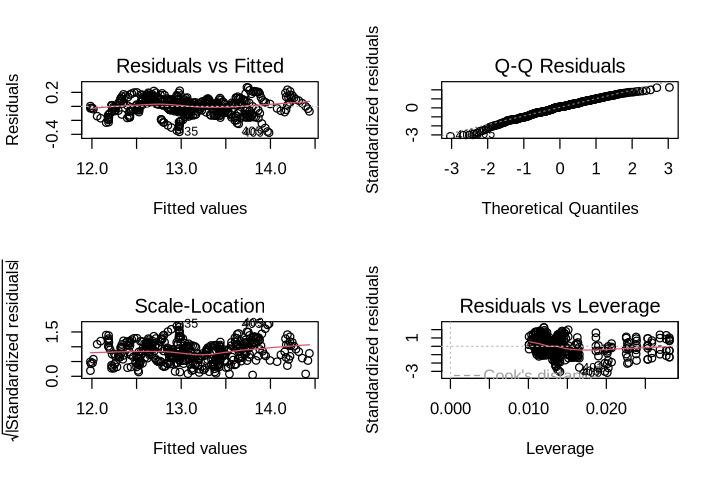

In [30]:
par(mfrow = c(2, 2))
plot(model)
par(mfrow = c(1, 1))

In [31]:
model_results <- tidy(model, conf.int = TRUE) |> 
                mutate(across(where(is.numeric), \(x) round(x, 7)))

print("Model Summary:")
print(model_results)

[1] "Model Summary:"
# A tibble: 6 × 7
  term                   estimate std.error statistic p.value conf.low conf.high
  <chr>                     <dbl>     <dbl>     <dbl>   <dbl>    <dbl>     <dbl>
1 (Intercept)             11.3      0.0326     348.         0  11.3      11.4   
2 housing_typeCondos      -0.340    0.0168     -20.3        0  -0.373    -0.307 
3 housing_typeSingle-de…   0.452    0.0168      27.0        0   0.419     0.485 
4 housing_typeTownhouses  -0.104    0.0168      -6.18       0  -0.137    -0.0708
5 income_10k               0.278    0.00360     77.2        0   0.271     0.285 
6 prime_interest_rate     -0.0283   0.00387     -7.32       0  -0.0359   -0.0207


In [32]:
model_performance <- glance(model)
print("Model Performance:")
print(model_performance)

[1] "Model Performance:"
# A tibble: 1 × 12
  r.squared adj.r.squared sigma statistic   p.value    df logLik   AIC   BIC
      <dbl>         <dbl> <dbl>     <dbl>     <dbl> <dbl>  <dbl> <dbl> <dbl>
1     0.955         0.954 0.120     1704. 7.25e-270     5   291. -567. -539.
# ℹ 3 more variables: deviance <dbl>, df.residual <int>, nobs <int>
